# Analysis of Residual Stream Activation Vectors (Raw + Deconfounded)

**Input files**:
- `INPUT_FILE` — a single `.pt` reasoning-vectors file produced by `run_fw_pass.py --type reasoning` with an additional deconfounding of the reasoning vectors with the pirncipal components of a chosen baseline dataset. Each layer contains:
  - `mean_correct_token`: global average of every correct reasoning token `[d_model]`
  - `mean_incorrect_token`: global average of every incorrect reasoning token `[d_model]`
  - `reasoning_direction_token`: `mean_correct_token - mean_incorrect_token` `[d_model]`
  - `per_sample_means`: per-sample average activation `[N_samples, d_model]`
  - `mean_correct_samples`: mean activation of perfectly-correct samples `[d_model]`
  - `mean_incorrect_samples`: mean activation of flawed samples `[d_model]`
  - `reasoning_direction_sample`: `mean_correct_samples - mean_incorrect_samples` `[d_model]`
  - `mean_correct_step`:          mean_correct_step,
  - `mean_incorrect_step`:        mean_incorrect_step,
  - `reasoning_direction_step`:   mean_correct_step - mean_incorrect_step,
    
          

- On the first run, do not have yet cleaned versions: 
  - `reasoning_direction_token_cleaned`: `reasoning_direction_token` deconfounded with chosen baseline
  - `reasoning_direction_sample_cleaned`: `reasoning_direction_sample` deconfounded with chosen baseline

**Analysis done**:
- Token and sample level (cosine) similarity of activations for reasoning (ProcessBench) dataset
- Unsupervised clustering method (Principal component analysis) for per-sample activation means
- Overlap of reasoning vectors with baseline principal components

## Set-up

In [28]:
!pip install matplotlib seaborn scikit-learn numpy torch --quiet

In [29]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import seaborn as sns
import math
import copy
from sklearn.decomposition import PCA
from pathlib import Path

sns.set_theme(style="whitegrid")

In [ ]:
# ── File paths ────────────────────────────────────────────────────────────────
# RAW AND DE-CONFOUNDED REASONING VECTORS FOR DIFF BASELINE DATASETS
INPUT_FILE_RAW_VECTORS = "/home/ines/Reasoning-activations/reasoning_vectors/Qwen3-8B/processbench/reasoning_vectors_Qwen3-8B_processbench_with_steps_avg.pt"
INPUT_FILE_CLEANED_VECTORS_FINEWEB = "/home/ines/Reasoning-activations/reasoning_vectors/Qwen3-8B/processbench/reasoning_vectors_cleaned_fineweb.pt"
INPUT_FILE_CLEANED_VECTORS_DEEPMIND_MATH = "/home/ines/Reasoning-activations/reasoning_vectors/Qwen3-8B/processbench/reasoning_vectors_cleaned_deepmind_math.pt"
INPUT_FILE_CLEANED_VECTORS_JOINT_FINEWEB_DEEPMIND_MATH = "/home/ines/Reasoning-activations/reasoning_vectors/Qwen3-8B/processbench/reasoning_vectors_cleaned_joint_fineweb_deepmind_math.pt"

# PCA COMPONENTS OF BASELINE DATASET
BASELINE_PCA_FILE_FINEWEB = "/home/ines/Reasoning-activations/reasoning_vectors/Qwen3-8B/fineweb_pca_components.pt"     
BASELINE_PCA_FILE_DEEPMIND_MATH = "/home/ines/Reasoning-activations/baseline_vectors/Qwen3-8B/deepmind_math_pca_components_20000samples.pt"
BASELINE_PCA_FILE_JOINT_FINEWEB_DEEPMIND_MATH = "/home/ines/Reasoning-activations/baseline_vectors/Qwen3-8B/joint_pca_fineweb_deepmind_40000samples.pt"


INPUT_FILE_CLEANED_VECTORS = INPUT_FILE_CLEANED_VECTORS_JOINT_FINEWEB_DEEPMIND_MATH

BASELINE_PCA = BASELINE_PCA_FILE_DEEPMIND_MATH

# the cleaned vectors baseline dataset must correspond with chosen baseline_pca file!!!

# 1. Extract components using pathlib
# file_path = Path(INPUT_FILE_CLEANED_VECTORS)
file_path = Path(INPUT_FILE_RAW_VECTORS)
path_parts = file_path.parts

# Find the index of 'reasoning_vectors' to relative-reference the next folders
rv_idx = path_parts.index("reasoning_vectors")
model_name = path_parts[rv_idx + 1]
reasoning_dataset = path_parts[rv_idx + 2]

# Extract baseline_dataset by removing prefix and suffix from the filename
# baseline_dataset = file_path.stem.replace("reasoning_vectors_cleaned_", "")
# Map the selected BASELINE_PCA to the desired baseline_dataset string
pca_to_dataset_name = {
    BASELINE_PCA_FILE_FINEWEB: "fineweb",
    BASELINE_PCA_FILE_DEEPMIND_MATH: "deepmind_math",
    BASELINE_PCA_FILE_JOINT_FINEWEB_DEEPMIND_MATH: "joint_fineweb_deepmind_math"
}

# Extract baseline_dataset dynamically (falls back to "unknown_baseline" if not found in dict)
baseline_dataset = pca_to_dataset_name.get(BASELINE_PCA, "unknown_baseline")

# 2. Define output directory and ensure it exists
out_dir = Path(f"/home/ines/Reasoning-activations/results/01_reasoning_vector_analysis/{model_name}/{reasoning_dataset}")
out_dir.mkdir(parents=True, exist_ok=True)

OUTPUT_FILE = file_path.parent / f"reasoning_vectors_with_step_cleaned_{baseline_dataset}.pt"

# ─────────────────────────────────────────────────────────────────────────────

## Load input file

In [31]:
data = torch.load(INPUT_FILE_RAW_VECTORS, map_location="cpu")

meta   = data["metadata"]
layers = data["layers"]

# Sort layer names by their integer index (e.g. "blocks.18.hook_out" → 18)
sorted_layer_names = sorted(
    layers.keys(),
    key=lambda x: int(x.split(".")[1])
)

# Per-sample correctness mask
is_perfect_mask = meta["per_sample_is_fully_correct"]   # bool tensor [N_samples]
y_mask          = is_perfect_mask.numpy()

print(f"Model          : {meta.get('model', 'N/A')}")
print(f"Target layers  : {meta.get('target_layers', 'N/A')}")
print(f"Correct tokens : {meta.get('count_correct_tokens', 'N/A')}")
print(f"Incorrect tokens : {meta.get('count_incorrect_tokens', 'N/A')}")
print(f"Correct steps : {meta.get('count_correct_steps', 'N/A')}")
print(f"Incorrect steps : {meta.get('count_incorrect_steps', 'N/A')}")
print(f"Perfect samples: {is_perfect_mask.sum().item()}")
print(f"Flawed samples : {(~is_perfect_mask).sum().item()}")
print(f"Layers found   : {sorted_layer_names}")

Model          : Qwen/Qwen3-8B
Target layers  : [18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
Correct tokens : 1212091
Incorrect tokens : 1085814
Correct steps : 14327
Incorrect steps : 2221
Perfect samples: 1179
Flawed samples : 2221
Layers found   : ['blocks.18.hook_out', 'blocks.19.hook_out', 'blocks.20.hook_out', 'blocks.21.hook_out', 'blocks.22.hook_out', 'blocks.23.hook_out', 'blocks.24.hook_out', 'blocks.25.hook_out', 'blocks.26.hook_out', 'blocks.27.hook_out', 'blocks.28.hook_out']


## Layer statistics - Token and sample level (cosine) similarity

- **Token-level cosine similarity**: angle between the global-average correct-token vector and the global-average incorrect-token vector. Values close to 1 indicate the model's activation is in roughly the same direction for both classes — most of the vector's "volume" is shared language-modeling signal.
- **Sample-level cosine similarity**: same idea but for the per-sample means (one vector per problem, averaged within each class).
- **Steering vector magnitude**: L2 norm of `reasoning_direction_token / reasoning_direction_sample` — the absolute geometric distance between the two class centres.

Identical results no matter the baseline dataset

=== Layer Statistics ===
  Token-Level  Cosine Sim  (Correct vs Incorrect): 0.995438
  Sample-Level Cosine Sim  (Perfect vs Flawed):    0.993949
  Step-Level Cosine Sim  (Correct vs Incorrect):   0.995143
  Cosine Sim (Token Dir vs Sample Dir): 0.721447
  Cosine Sim (Step Dir vs Sample Dir): 0.907730
  Cosine Sim (Token Dir vs Step Dir): 0.685594
  Token  Steering Vec Magnitude: 7.4642
  Sample Steering Vec Magnitude: 9.1806
  Step   Steering Vec Magnitude: 7.9262

  Token-Level  Cosine Sim  (Correct vs Incorrect): 0.993907
  Sample-Level Cosine Sim  (Perfect vs Flawed):    0.994051
  Step-Level Cosine Sim  (Correct vs Incorrect):   0.995121
  Cosine Sim (Token Dir vs Sample Dir): 0.706698
  Cosine Sim (Step Dir vs Sample Dir): 0.884359
  Cosine Sim (Token Dir vs Step Dir): 0.656261
  Token  Steering Vec Magnitude: 9.8608
  Sample Steering Vec Magnitude: 10.2655
  Step   Steering Vec Magnitude: 8.9788

  Token-Level  Cosine Sim  (Correct vs Incorrect): 0.993847
  Sample-Level Cosine Si

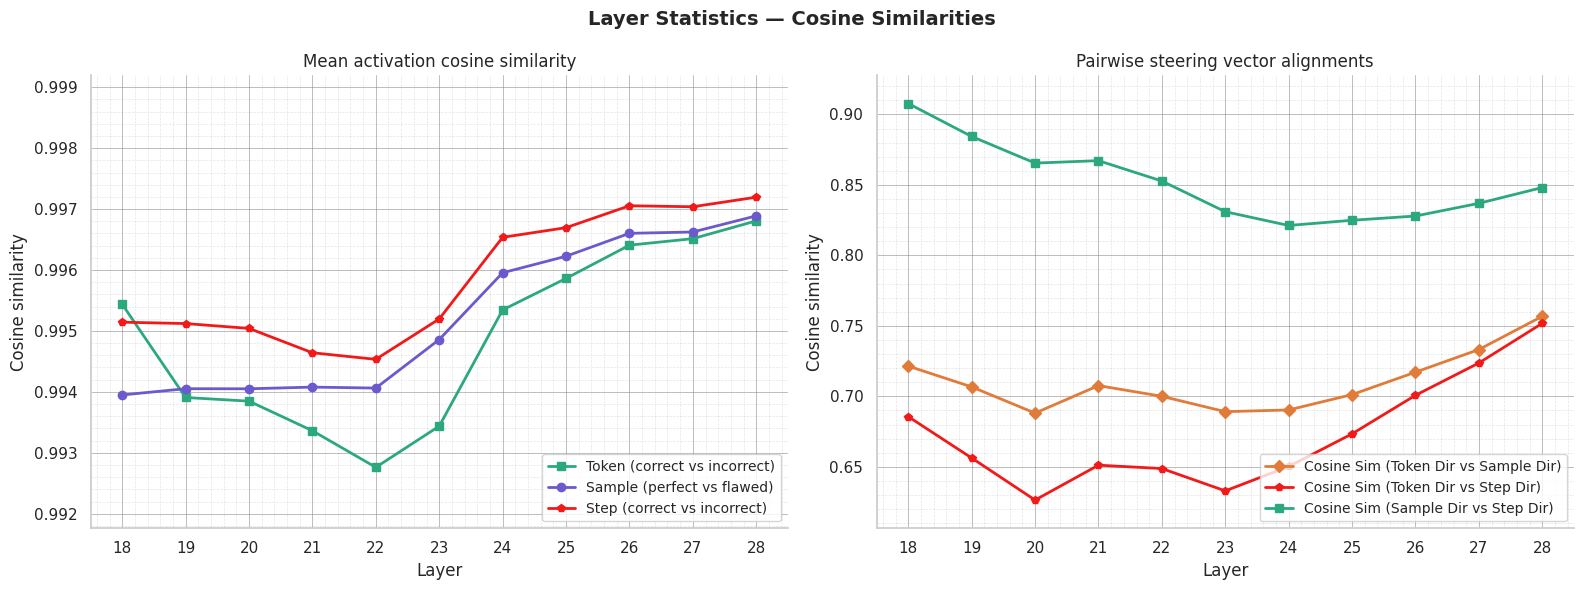

In [32]:
print("=== Layer Statistics ===")

sorted_layer_names = sorted(layers.keys())
layer_indices = [int(name.split(".")[1]) for name in sorted_layer_names]

token_cos_sim, sample_cos_sim, step_cos_sim = [], [], []
tok_samp_sim, tok_step_sim, samp_step_sim = [], [], []

for layer_name in sorted_layer_names:
    ld = layers[layer_name]

    token_sim = F.cosine_similarity(
        ld["mean_correct_token"].unsqueeze(0),
        ld["mean_incorrect_token"].unsqueeze(0)
    ).item()
    print(f"  Token-Level  Cosine Sim  (Correct vs Incorrect): {token_sim:.6f}")

    sample_sim = F.cosine_similarity(
        ld["mean_correct_samples"].unsqueeze(0),
        ld["mean_incorrect_samples"].unsqueeze(0)
    ).item()
    print(f"  Sample-Level Cosine Sim  (Perfect vs Flawed):    {sample_sim:.6f}")

    step_sim = F.cosine_similarity(
        ld["mean_correct_step"].unsqueeze(0),
        ld["mean_incorrect_step"].unsqueeze(0)
    ).item()
    print(f"  Step-Level Cosine Sim  (Correct vs Incorrect):   {step_sim:.6f}")

    alignment = F.cosine_similarity(
        ld["reasoning_direction_token"].unsqueeze(0),
        ld["reasoning_direction_sample"].unsqueeze(0)
    ).item()
    print(f"  Cosine Sim (Token Dir vs Sample Dir): {alignment:.6f}")

    alignment_step_sample = F.cosine_similarity(
        ld["reasoning_direction_step"].unsqueeze(0),
        ld["reasoning_direction_sample"].unsqueeze(0)
    ).item()
    print(f"  Cosine Sim (Step Dir vs Sample Dir): {alignment_step_sample:.6f}")

    alignment_step_token = F.cosine_similarity(
        ld["reasoning_direction_token"].unsqueeze(0),
        ld["reasoning_direction_step"].unsqueeze(0)
    ).item()
    print(f"  Cosine Sim (Token Dir vs Step Dir): {alignment_step_token:.6f}")

    # Steering vector magnitudes
    token_mag  = torch.norm(ld["reasoning_direction_token"]).item()
    sample_mag = torch.norm(ld["reasoning_direction_sample"]).item()
    step_mag   = torch.norm(ld["reasoning_direction_step"]).item()
    print(f"  Token  Steering Vec Magnitude: {token_mag:.4f}")
    print(f"  Sample Steering Vec Magnitude: {sample_mag:.4f}")
    print(f"  Step   Steering Vec Magnitude: {step_mag:.4f}\n")

    token_cos_sim.append(token_sim)
    sample_cos_sim.append(sample_sim)
    step_cos_sim.append(step_sim)

    tok_samp_sim.append(alignment)
    tok_step_sim.append(alignment_step_token)
    samp_step_sim.append(alignment_step_sample)

# ── Plot ──────────────────────────────────────────────────────────────────
PURPLE, GREEN, ORANGE, RED = "#6a5acd", "#2ca87f", "#e07b39", "#F21919"

# 1) Increased figsize for better visibility
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Layer Statistics — Cosine Similarities", fontsize=14, fontweight="bold")

# Ax1: Mean activation cosine similarity
ax1.plot(layer_indices, token_cos_sim,  "s-", color=GREEN,  lw=2, label="Token (correct vs incorrect)")
ax1.plot(layer_indices, sample_cos_sim, "o-", color=PURPLE, lw=2, label="Sample (perfect vs flawed)")
ax1.plot(layer_indices, step_cos_sim,   "p-", color=RED,    lw=2, label="Step (correct vs incorrect)")

ax1.set_title("Mean activation cosine similarity")
ax1.set_ylabel("Cosine similarity")

# 2) Safe Y-Limits capped at 1.0 for cosine similarity
min_ax1 = min(token_cos_sim + sample_cos_sim + step_cos_sim) - 0.001
max_ax1 = min(1.0, max(token_cos_sim + sample_cos_sim + step_cos_sim) + 0.002)
ax1.set_ylim(min_ax1, max_ax1)
ax1.legend(fontsize=10, loc="lower right")

# Ax2: Pairwise Steering vector alignment
ax2.plot(layer_indices, tok_samp_sim,  "D-", color=ORANGE, lw=2, label="Cosine Sim (Token Dir vs Sample Dir)")
ax2.plot(layer_indices, tok_step_sim,  "p-", color=RED,    lw=2, label="Cosine Sim (Token Dir vs Step Dir)")
ax2.plot(layer_indices, samp_step_sim, "s-", color=GREEN,  lw=2, label="Cosine Sim (Sample Dir vs Step Dir)")

# 3) Fixed Title to include Step
ax2.set_title("Pairwise steering vector alignments")
ax2.set_ylabel("Cosine similarity")

# 4) Safe Y-Limits capped at 1.0 (and removed the weird partial fill_between)
min_ax2 = min(tok_samp_sim + tok_step_sim + samp_step_sim) - 0.02
max_ax2 = min(1.0, max(tok_samp_sim + tok_step_sim + samp_step_sim) + 0.02)
ax2.set_ylim(min_ax2, max_ax2)
ax2.legend(fontsize=10, loc="lower right")

for ax in (ax1, ax2):
    ax.set_xlabel("Layer")
    ax.set_xticks(layer_indices)
    ax.minorticks_on()
    ax.grid(True, which="major", alpha=0.6, color="gray", linestyle="-", lw=0.6)
    ax.grid(True, which="minor", alpha=0.2, color="gray", linestyle="--", lw=0.5)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(out_dir / f"layer_cosine_similarities_with_step_vector.png", dpi=150, bbox_inches="tight")
plt.show()

- Calculate the cosine similarity between correct and incorrect reasoning vectors across all targeted layers. If the similarity is low, it suggests the model is in a distinctly different state when hallucinating / incorrectly reasoning versus when reasoning correctly.
- interesting to see cosine similarity with average vector on baseline dataset, layer wise?

## Load baseline PCA components

In [33]:
baseline_pca = torch.load(BASELINE_PCA, map_location="cpu")
pca_by_layer = baseline_pca["layers"]   # keys are int layer indices
    
def get_baseline_components(layer_name: str):
    """
    Look up PCA components for a layer whose name is e.g. 'blocks.18.hook_out'.
    This unified version supports dictionaries with either string keys or integer keys.
    Returns a numpy array of shape [n_components, d_model].
    """
    # Option 1: The dictionary uses the exact string as the key
    if layer_name in pca_by_layer:
        return pca_by_layer[layer_name].to(torch.float32).numpy()
    
    # Option 2: The dictionary uses integer keys (fallback)
    try:
        layer_idx = int(layer_name.split(".")[1])
        return pca_by_layer[layer_idx].to(torch.float32).numpy()
    except (IndexError, ValueError) as e:
        raise KeyError(f"Could not find key '{layer_name}' or its integer index in pca_by_layer.") from e
    
def project_out_components(vec: torch.Tensor, components: np.ndarray) -> torch.Tensor:
    """
    Project out a set of (orthogonal, unit-norm) PCA components from a vector.
    Works for both 1-D vectors [d_model] and 2-D matrices [N, d_model].
    """
    x = vec.to(torch.float32).numpy().copy()
    original_shape = x.shape
    if x.ndim == 1:
        x = x.reshape(1, -1)
    for comp in components:                              # comp: [d_model]
        projection = x @ comp                           # [N]
        x -= projection[:, None] * comp[None, :]        # subtract component
    return torch.tensor(x.reshape(original_shape), dtype=vec.dtype)


print("Baseline PCA file loaded.")
print(f"Layers in baseline file: {list(pca_by_layer.keys())}")

Baseline PCA file loaded.
Layers in baseline file: [18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]


## Compute overlap of (original) reasoning vectors with the baseline subspace
Compute the percentage of the original reasoning direction vector's magnitude that is captured by (or "lies within") the Principal Component (PCA) subspace of the baseline dataset.


We subtract the projection of each steering vector onto the basline PC subspace. This removes variance that is shared with generic language processing, leaving a cleaner signal that is more specific to the *correctness* of mathematical reasoning.



=== Projecting out baseline PCA components ===
Layer blocks.18.hook_out  (3 components)  |  token: 7.464→7.400 (13.1%)  |  sample: 9.181→9.098 (13.4%)  |  step: 7.926→7.830 (15.5%)
Layer blocks.19.hook_out  (3 components)  |  token: 9.861→9.712 (17.3%)  |  sample: 10.265→10.137 (15.8%)  |  step: 8.979→8.804 (19.6%)
Layer blocks.20.hook_out  (3 components)  |  token: 10.101→10.027 (12.1%)  |  sample: 10.428→10.333 (13.5%)  |  step: 9.407→9.236 (19.0%)
Layer blocks.21.hook_out  (3 components)  |  token: 11.570→11.516 (9.6%)  |  sample: 11.679→11.554 (14.6%)  |  step: 10.877→10.704 (17.8%)
Layer blocks.22.hook_out  (4 components)  |  token: 13.485→13.410 (10.5%)  |  sample: 12.985→12.829 (15.4%)  |  step: 12.275→12.010 (20.7%)
Layer blocks.23.hook_out  (4 components)  |  token: 15.658→15.650 (3.2%)  |  sample: 14.261→14.201 (9.1%)  |  step: 13.547→13.445 (12.3%)
Layer blocks.24.hook_out  (4 components)  |  token: 17.626→17.567 (8.2%)  |  sample: 16.459→16.404 (8.2%)  |  step: 15.144→15.06

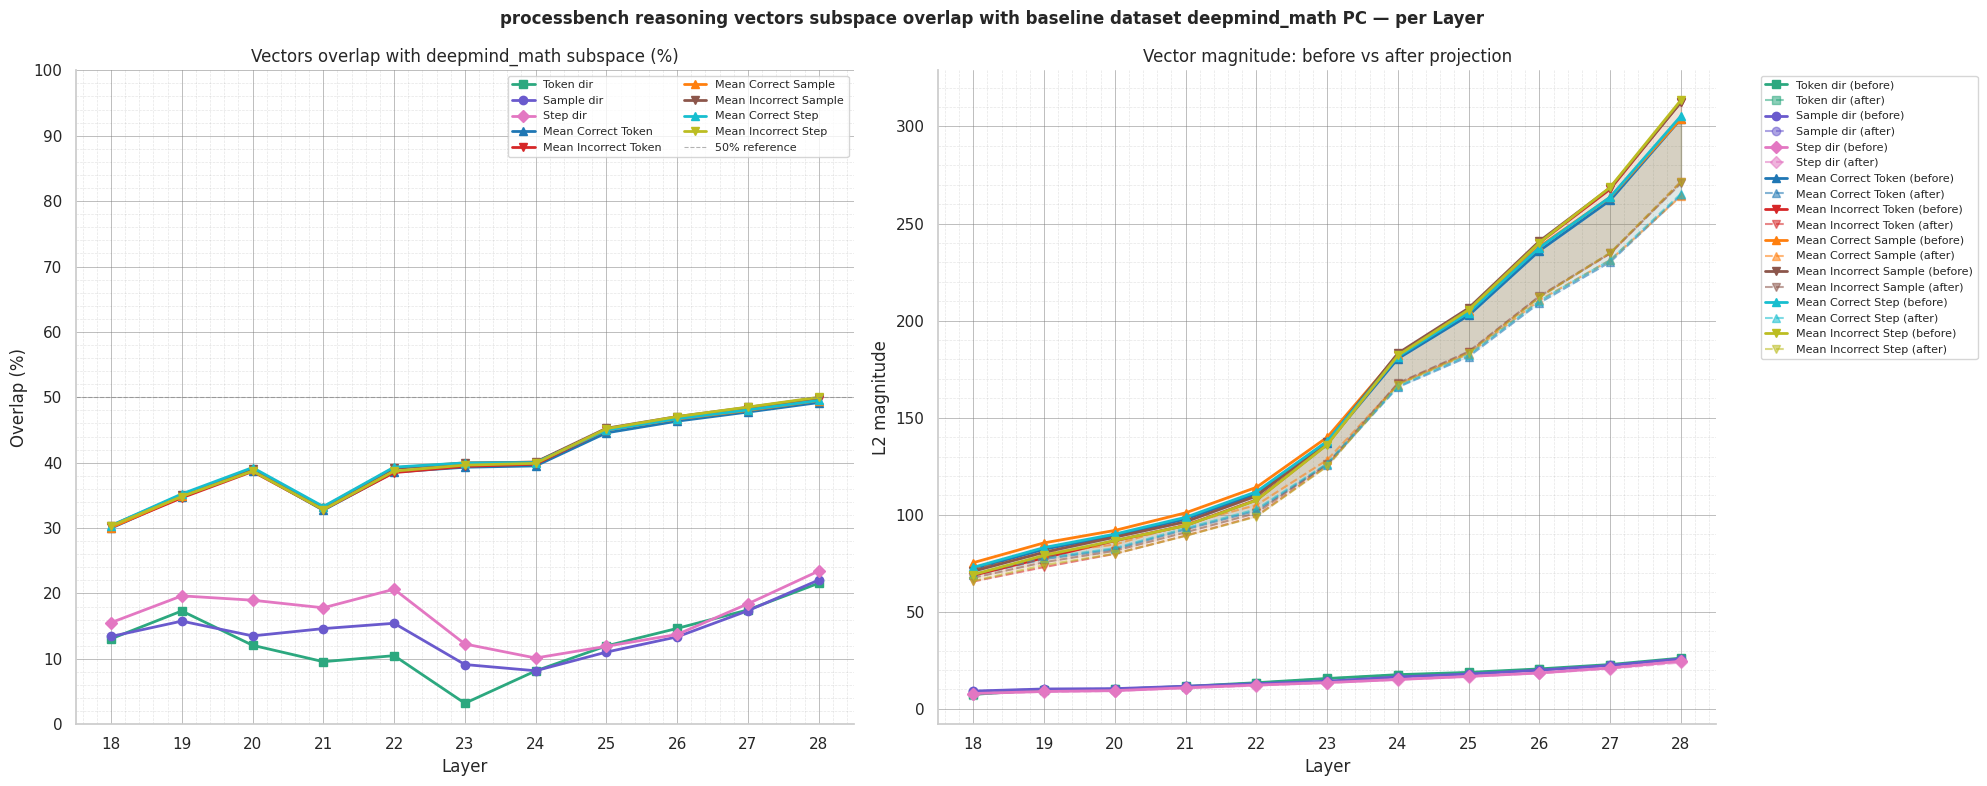

In [34]:
print("=== Projecting out baseline PCA components ===")

# 1. Setup mapping for all 9 target vectors we are analyzing
key_mapping = {
    "rd_token":  "reasoning_direction_token",
    "rd_sample": "reasoning_direction_sample",
    "rd_step":   "reasoning_direction_step",
    "mct":       "mean_correct_token",
    "mit":       "mean_incorrect_token",
    "mcs":       "mean_correct_samples",
    "mis":       "mean_incorrect_samples",
    "mc_step":   "mean_correct_step",
    "mi_step":   "mean_incorrect_step"
}
keys = list(key_mapping.keys())

# 2. RENAMED: Use `plot_metrics` so we don't overwrite the global PyTorch `data` variable!
plot_metrics = {
    "overlap_pct": {k: [] for k in keys},
    "mag_before":  {k: [] for k in keys},
    "mag_after":   {k: [] for k in keys}
}
valid_layer_indices = []

# Helper function to prevent redundant overlap calculation code
def get_overlap(vec, orig_mag, comps):
    vec_np = vec.to(torch.float32).numpy()
    dot_vals = torch.tensor(np.array([
        np.dot(vec_np / (orig_mag + 1e-12), c) for c in comps
    ]))
    return torch.sqrt((dot_vals**2).sum()).item()

for layer_name in sorted_layer_names:
    ld = layers[layer_name]

    try:
        components = get_baseline_components(layer_name)
    except KeyError as e:
        print(f"  WARNING: {e}. Skipping layer.")
        continue

    n_comp = components.shape[0]

    vecs = {}
    vecs_cleaned = {}

    # Extract baseline vectors and check/compute cleaned versions dynamically
    for k, full_name in key_mapping.items():
        vecs[k] = ld[full_name]
        
        cleaned_name = f"{full_name}_cleaned"
        if cleaned_name in ld:
            vecs_cleaned[k] = ld[cleaned_name]
        else:
            # Project out the components
            vecs_cleaned[k] = project_out_components(vecs[k], components)
            
            # FIXED: Save the computed cleaned vector back into `ld` (and thus `data`) in-place!
            ld[cleaned_name] = vecs_cleaned[k]

    log_strs = []
    # Compute everything in a simple loop over the 9 keys
    for k in keys:
        orig_mag = torch.norm(vecs[k]).item()
        clean_mag = torch.norm(vecs_cleaned[k]).item()
        overlap = get_overlap(vecs[k], orig_mag, components)
        
        plot_metrics["overlap_pct"][k].append(overlap * 100)
        plot_metrics["mag_before"][k].append(orig_mag)
        plot_metrics["mag_after"][k].append(clean_mag)
        
        # Keep the printed log concise by only formatting directions
        if k in ["rd_token", "rd_sample", "rd_step"]:
            name = k.replace("rd_", "")
            log_strs.append(f"{name}: {orig_mag:.3f}→{clean_mag:.3f} ({overlap*100:.1f}%)")

    valid_layer_indices.append(int(layer_name.split(".")[1]))

    print(f"Layer {layer_name}  ({n_comp} components)  |  " + "  |  ".join(log_strs))

print("\n=== Projection complete ===")

# ── Plot ──────────────────────────────────────────────────────────────────
# Extend styling definitions for the 9 different series
colors = {
    "rd_token":  "#2ca87f", # GREEN
    "rd_sample": "#6a5acd", # PURPLE
    "rd_step":   "#e377c2", # PINK
    "mct":       "#1f77b4", # BLUE
    "mit":       "#d62728", # RED
    "mcs":       "#ff7f0e", # ORANGE
    "mis":       "#8c564b", # BROWN
    "mc_step":   "#17becf", # CYAN
    "mi_step":   "#bcbd22"  # OLIVE
}

labels = {
    "rd_token":  "Token dir",
    "rd_sample": "Sample dir",
    "rd_step":   "Step dir",
    "mct":       "Mean Correct Token",
    "mit":       "Mean Incorrect Token",
    "mcs":       "Mean Correct Sample",
    "mis":       "Mean Incorrect Sample",
    "mc_step":   "Mean Correct Step",
    "mi_step":   "Mean Incorrect Step"
}

markers = {
    "rd_token":  "s",
    "rd_sample": "o",
    "rd_step":   "D",
    "mct":       "^",
    "mit":       "v",
    "mcs":       "^",
    "mis":       "v",
    "mc_step":   "^",
    "mi_step":   "v"
}

# Increased width slightly to accommodate the larger outer legend
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle(f"{reasoning_dataset} reasoning vectors subspace overlap with baseline dataset {baseline_dataset} PC — per Layer", fontsize=12, fontweight="bold")

# Left: overlap %
for k in keys:
    ax1.plot(valid_layer_indices, plot_metrics["overlap_pct"][k], f"{markers[k]}-", color=colors[k], lw=2, label=labels[k])
    
ax1.axhline(50, color="gray", lw=0.8, ls="--", alpha=0.6, label="50% reference")
ax1.set_title(f"Vectors overlap with {baseline_dataset} subspace (%)")
ax1.set_ylabel("Overlap (%)")
ax1.set_ylim(0, 100)
ax1.set_yticks(range(0, 101, 10)) 
ax1.legend(fontsize=8, ncol=2)

# Right: magnitude before vs after
for k in keys:
    ax2.plot(valid_layer_indices, plot_metrics["mag_before"][k], f"{markers[k]}-",  color=colors[k], lw=2, label=f"{labels[k]} (before)")
    ax2.plot(valid_layer_indices, plot_metrics["mag_after"][k],  f"{markers[k]}--", color=colors[k], lw=1.5, alpha=0.55, label=f"{labels[k]} (after)")
    ax2.fill_between(valid_layer_indices, plot_metrics["mag_after"][k], plot_metrics["mag_before"][k], color=colors[k], alpha=0.07)

ax2.set_title("Vector magnitude: before vs after projection")
ax2.set_ylabel("L2 magnitude")
# Moved legend outside bounds since 18 lines will clutter the chart heavily
ax2.legend(fontsize=8, ncol=1, bbox_to_anchor=(1.05, 1), loc='upper left')

for ax in (ax1, ax2):
    ax.set_xlabel("Layer")
    ax.set_xticks(valid_layer_indices)
    
    ax.minorticks_on()
    ax.grid(True, which="major", alpha=0.6, color="gray", linestyle="-", lw=0.6)
    ax.grid(True, which="minor", alpha=0.2, color="gray", linestyle="--", lw=0.5)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(out_dir / f"overlap_projection_{baseline_dataset}_extended.png", dpi=150, bbox_inches="tight")
plt.show()

## Save output file

The output `.pt` file is identical to the input, with two additional keys per layer:
- `reasoning_direction_token_cleaned`
- `reasoning_direction_sample_cleaned`

In [35]:
# data["layers"] was modified in-place above, so we can save directly.
torch.save(data, OUTPUT_FILE)
print(f"Saved enriched reasoning vectors to '{OUTPUT_FILE}'.")

# Verify
check = torch.load(OUTPUT_FILE, map_location="cpu")
sample_layer = sorted_layer_names[0]
keys = list(check["layers"][sample_layer].keys())
print(f"Keys in '{sample_layer}': {keys}")

Saved enriched reasoning vectors to '/home/ines/Reasoning-activations/reasoning_vectors/Qwen3-8B/processbench/reasoning_vectors_with_step_cleaned_deepmind_math.pt'.
Keys in 'blocks.18.hook_out': ['mean_correct_token', 'mean_incorrect_token', 'reasoning_direction_token', 'mean_correct_step', 'mean_incorrect_step', 'reasoning_direction_step', 'per_sample_means', 'mean_correct_samples', 'mean_incorrect_samples', 'reasoning_direction_sample', 'reasoning_direction_token_cleaned', 'reasoning_direction_sample_cleaned', 'reasoning_direction_step_cleaned', 'mean_correct_token_cleaned', 'mean_incorrect_token_cleaned', 'mean_correct_samples_cleaned', 'mean_incorrect_samples_cleaned', 'mean_correct_step_cleaned', 'mean_incorrect_step_cleaned']


In [36]:
print("=== Analyzing Overlap: Reasoning Vectors vs Baseline PCA Subspace ===")

for layer_name in sorted_layer_names:
    # components = pca_by_layer[layer_name].to(torch.float32)   # [n_comp, d_model]

    # Option 1: The dictionary uses the exact string as the key
    if layer_name in pca_by_layer:
        components =  pca_by_layer[layer_name].to(torch.float32)
    # Option 2: The dictionary uses integer keys (fallback)
    else:
        layer_idx = int(layer_name.split(".")[1])
        components =  pca_by_layer[layer_idx].to(torch.float32)
    
    n_comp = components.shape[0]

    ld = layers[layer_name]

    for vec_key, label in [
        ("reasoning_direction_token",  "Token  direction"),
        ("reasoning_direction_sample", "Sample direction"),
    ]:
        v = ld[vec_key].to(torch.float32)
        v_norm = torch.norm(v)
        if v_norm == 0:
            print(f"  {label}: zero vector, skipping.")
            continue

        v_unit = v / v_norm

        # Cosine similarity of the (unit) steering vector against every PCA component at once.
        # components rows are already unit vectors, so matmul gives exact cosine sims.
        dot_products = components @ v_unit                          # [n_comp]

        max_cos_sim        = torch.max(torch.abs(dot_products)).item()
        total_subspace_overlap = torch.sqrt((dot_products**2).sum()).item()

        print(f"\nLayer: {layer_name}  |  {label}  ({n_comp} PCA components)")
        print(f"  Max cosine sim with any single component : {max_cos_sim:.4f}")
        print(f"  Total subspace overlap ratio             : {total_subspace_overlap:.4f} "
              f"({total_subspace_overlap*100:.1f}% of vector magnitude lies in Baseline subspace)")

print("\n=== Overlap analysis complete ===")

=== Analyzing Overlap: Reasoning Vectors vs Baseline PCA Subspace ===

Layer: blocks.18.hook_out  |  Token  direction  (3 PCA components)
  Max cosine sim with any single component : 0.0936
  Total subspace overlap ratio             : 0.1306 (13.1% of vector magnitude lies in Baseline subspace)

Layer: blocks.18.hook_out  |  Sample direction  (3 PCA components)
  Max cosine sim with any single component : 0.1008
  Total subspace overlap ratio             : 0.1342 (13.4% of vector magnitude lies in Baseline subspace)

Layer: blocks.19.hook_out  |  Token  direction  (3 PCA components)
  Max cosine sim with any single component : 0.1382
  Total subspace overlap ratio             : 0.1733 (17.3% of vector magnitude lies in Baseline subspace)

Layer: blocks.19.hook_out  |  Sample direction  (3 PCA components)
  Max cosine sim with any single component : 0.1113
  Total subspace overlap ratio             : 0.1577 (15.8% of vector magnitude lies in Baseline subspace)

Layer: blocks.20.hook_out